<a href="https://www.kaggle.com/code/zulqarnain11/butterfly-image-classification-using-yolo?scriptVersionId=290807599" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="border-radius: 30px 0 30px 0px;
            border: 2px solid #00ea98;
            padding: 28px;
            background-color: #0a141b;
            text-align: center;
            box-shadow: 0px 2px 6px rgba(0, 0, 0, 0.3);">

 <h1 style="color: #7ab052;
               text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5);
               font-weight: bold;
               font-size: 40px;
               margin-bottom: 10px;">
        🦋 Butterfly Image Classification using YOLOv8
</h1>

 <h3 style="color: #c8e6c9;
               font-weight: normal;
               font-size: 20px;
               margin-top: 8px;">
        🚀 Transfer Learning for Multi-Class Image Classification (75 Classes)
 </h3>

</div>


<div style="border-radius: 30px 0 30px 0px; border: 2px solid #00ea98; padding: 20px; background-color: #0a141b; text-align: center; box-shadow: 0px 2px 4px rgba(0, 0, 0, 0.2);">
    <h1 style="color: #7ab052; font-size: 34px; font-weight: bold;">
        🦋 0 | Problem Statement
    </h1>
    <p style="color: #ffffff; font-size: 16px; margin-top: 12px;">
        The objective of this project is to build a robust deep learning model capable of accurately classifying
        butterfly species from images. The dataset consists of 75 different butterfly classes, where each image
        belongs to exactly one category. Using transfer learning with YOLOv8, we aim to learn discriminative visual
        features and generate predictions for unseen test images.
    </p>
</div>


<div style="border-radius: 30px 0 30px 0px; border: 2px solid #00BFFF; padding: 20px; background-color: #0a141b; text-align: center;">
    <h1 style="color: #00e5ff; font-size: 30px; font-weight: bold;">
        📂 1 | Dataset Description
    </h1>
    <p style="color: #ffffff; font-size: 16px;">
        The dataset contains labeled butterfly images distributed across 75 species.
        Labels are provided via CSV files, and images are stored in separate train and test folders.
    </p>
    <ul style="color: #ffffff; text-align: left; display: inline-block;">
        <li>🖼️ Total Classes: 75</li>
        <li>📁 Training Images: ~5,000+</li>
        <li>📁 Validation Images: ~1,300</li>
        <li>📄 Labels stored in <b>Training_set.csv</b></li>
        <li>📄 Test filenames stored in <b>Testing_set.csv</b></li>
    </ul>
</div>


<div style="border-radius: 30px 0 30px 0px; border: 2px solid #ff9800; padding: 20px; background-color: #0a141b; text-align: center;">
    <h1 style="color: #ffb74d; font-size: 30px; font-weight: bold;">
        📦 2 | Importing Required Libraries
    </h1>
</div>


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import kagglehub
import shutil
from ultralytics import  YOLO


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


<div style="border-radius: 30px 0 30px 0px; border: 2px solid #ab47bc; padding: 20px; background-color: #0a141b; text-align: center;">
    <h1 style="color: #ce93d8; font-size: 30px; font-weight: bold;">
        ⬇️ 3 | Downloading Dataset
    </h1>
</div>


In [5]:
# Download latest version
path = kagglehub.dataset_download("phucthaiv02/butterfly-image-classification")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/butterfly-image-classification


<div style="border-radius: 30px 0 30px 0px; border: 2px solid #4caf50; padding: 20px; background-color: #0a141b; text-align: center;">
    <h1 style="color: #81c784; font-size: 30px; font-weight: bold;">
        🧾 4 | Loading Metadata
    </h1>
</div>


In [12]:
train_df=pd.read_csv('/kaggle/input/butterfly-image-classification/Training_set.csv')
test_df=pd.read_csv('/kaggle/input/butterfly-image-classification/Testing_set.csv')
train_image_dir='/kaggle/input/butterfly-image-classification/train'
test_image_dir='/kaggle/input/butterfly-image-classification/test'

In [13]:
train_df.head()

,filename,label
0,Image_1.jpg,SOUTHERN DOGFACE
1,Image_2.jpg,ADONIS
2,Image_3.jpg,BROWN SIPROETA
3,Image_4.jpg,MONARCH
4,Image_5.jpg,GREEN CELLED CATTLEHEART


<div style="border-radius: 30px 0 30px 0px; border: 2px solid #f44336; padding: 20px; background-color: #0a141b; text-align: center;">
    <h1 style="color: #ef9a9a; font-size: 30px; font-weight: bold;">
        🔀 5 | Train-Validation Split
    </h1>
</div>


In [14]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["label"],
    random_state=42
)


<div style="border-radius: 30px 0 30px 0px; border: 2px solid #03a9f4; padding: 20px; background-color: #0a141b; text-align: center;">
    <h1 style="color: #81d4fa; font-size: 30px; font-weight: bold;">
        🗂️ 6 | Dataset Preparation for YOLO
    </h1>
</div>


In [30]:
dataset_dir = "/kaggle/working/butterfly_dataset"
os.makedirs(dataset_dir, exist_ok=True)


def csv_to_folders(df, split_name):
    for _, row in df.iterrows():
        label = row["label"]
        img = row["filename"]

        src_img = os.path.join(train_image_dir, img)

        dest_dir = os.path.join(dataset_dir, split_name, label)
        os.makedirs(dest_dir, exist_ok=True)

        dest_img = os.path.join(dest_dir, img)

        if os.path.exists(src_img):
            shutil.copy(src_img, dest_img)


In [31]:
test_dir = "/kaggle/working/test"
os.makedirs(test_dir, exist_ok=True)

for img in test_df["filename"]:
    src = os.path.join(test_image_dir, img)
    dst = os.path.join(test_dir, img)
    if os.path.exists(src):
        shutil.copy(src, dst)


csv_to_folders(train_df, "train")
csv_to_folders(val_df, "val")

<div style="border-radius: 30px 0 30px 0px; border: 2px solid #00e676; padding: 20px; background-color: #0a141b; text-align: center;">
    <h1 style="color: #69f0ae; font-size: 30px; font-weight: bold;">
        🧠 7 | Training YOLOv8 Classification Model
    </h1>
</div>


In [33]:
model=YOLO('yolov8m-cls.pt')
result=model.train(
    data='butterfly_dataset',
    epochs=10,
    imgsz=224
)

Ultralytics 8.3.250 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=butterfly_dataset, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pr

<div style="border-radius: 30px 0 30px 0px; border: 2px solid #ffc107; padding: 20px; background-color: #0a141b; text-align: center;">
    <h1 style="color: #ffe082; font-size: 30px; font-weight: bold;">
        📊 8 | Training Performance
    </h1>
</div>


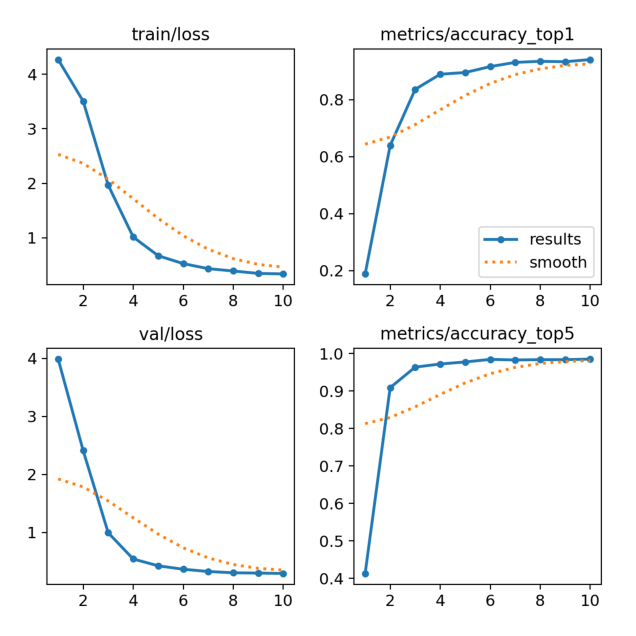

In [35]:
img = mpimg.imread('/kaggle/working/runs/classify/train/results.png')

plt.figure(figsize=(14,8))
plt.imshow(img)
plt.axis('off')
plt.show()


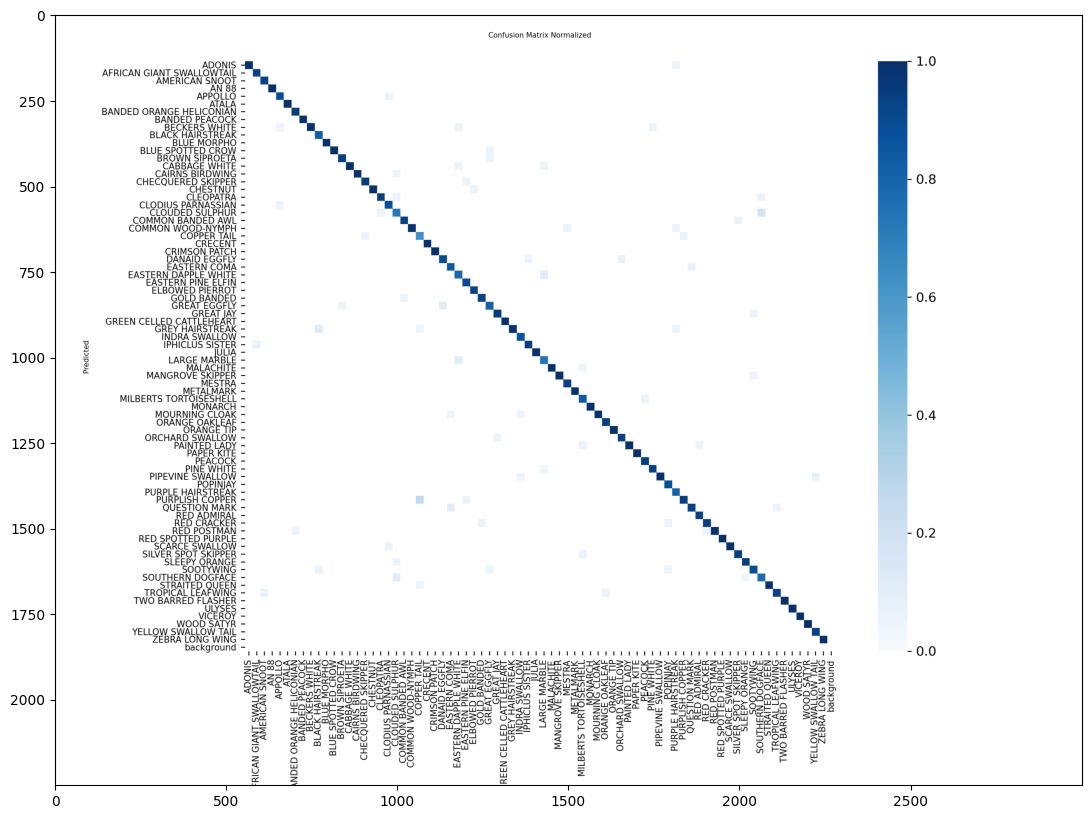

In [36]:
img=mpimg.imread('/kaggle/working/runs/classify/train/confusion_matrix_normalized.png')
plt.figure(figsize=(14,10))
plt.imshow(img)


<div style="border-radius: 30px 0 30px 0px; border: 2px solid #e91e63; padding: 20px; background-color: #0a141b; text-align: center;">
    <h1 style="color: #f48fb1; font-size: 30px; font-weight: bold;">
        🧪 9 | Test Predictions
    </h1>
</div>


In [43]:
model=YOLO('/kaggle/working/runs/classify/train/weights/best.pt')

results = model.predict(
    source="/kaggle/working/test",
    save=True,
    verbose=False
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Results saved to /kaggle/working/runs/classify/predict


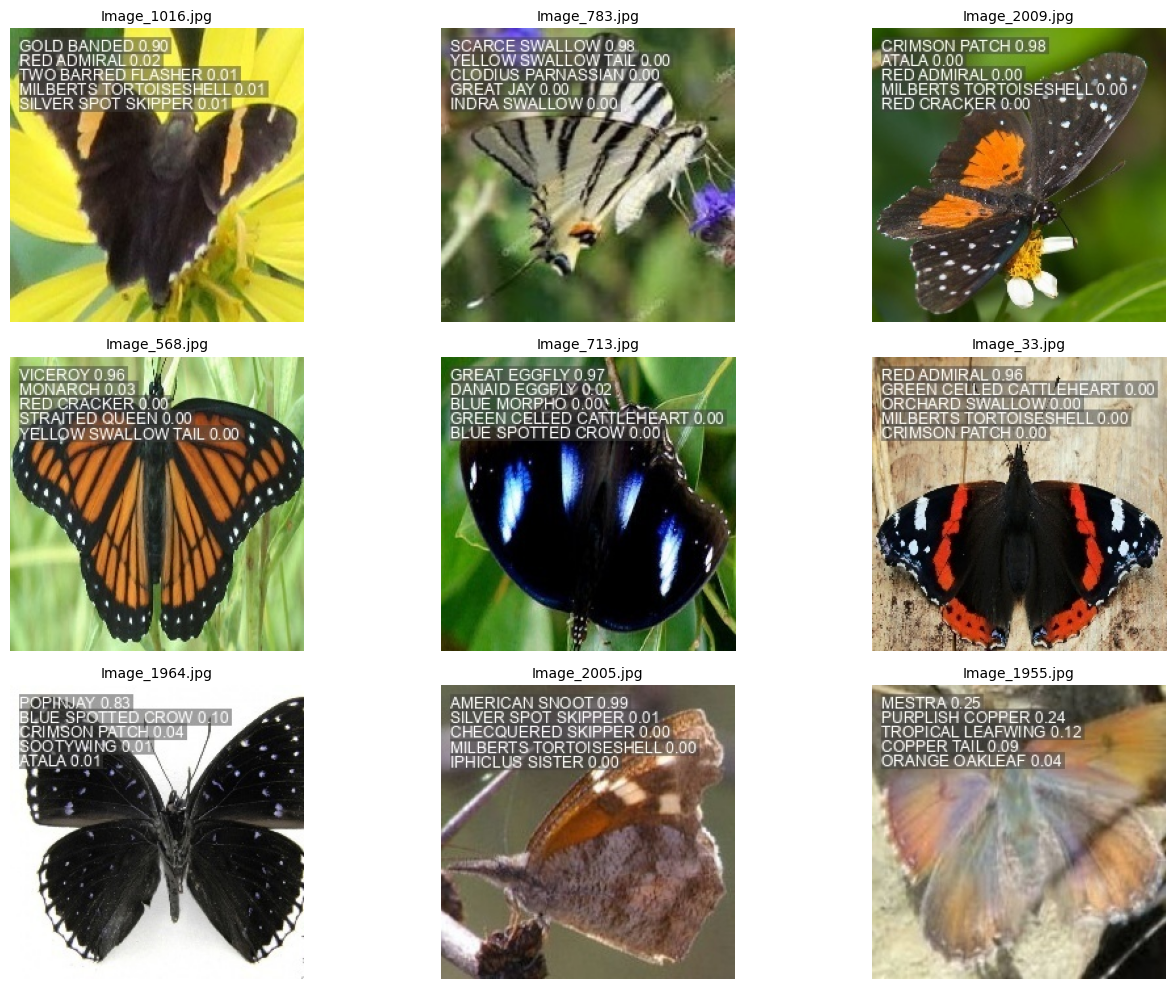

In [45]:
Result_images_folder = '/kaggle/working/runs/classify/predict'
Result_images = os.listdir(Result_images_folder)

plt.figure(figsize=(14, 10))

for i, image_name in enumerate(Result_images[:9]):
    image_path = os.path.join(Result_images_folder, image_name)
    img = mpimg.imread(image_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(image_name, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

<div style="border-radius: 20px; border: 2px solid #00ea98; padding: 18px; background-color: #0a141b; text-align: center;">
    <h3 style="color: #7ab052;">
        🚀 If you found this notebook helpful, consider upvoting 👍  
        <br>Feedback & collaborations are always welcome!
    </h3>
</div>
